In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# Set the path to your dataset
dataset_BrainTumorLabeled = '/brainTumorDetection/raw_data/brainTumorLabeledDataset'
# main_path = "/content/drive/MyDrive/raw_data/"


In [4]:
from brainTumorDetection.ml_logic.preprocessingData.splitData import custom_train_test_split


In [9]:
custom_train_test_split(dataset_BrainTumorLabeled)

FileNotFoundError: [Errno 2] No such file or directory: '/brainTumorDetection/raw_data/brainTumorLabeledDataset'

In [4]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Configuration de l'ImageDataGenerator
datagen = ImageDataGenerator(
     rescale=1./255,  # Normaliser les pixels entre 0 et 1
    rotation_range=20,  # Rotation aléatoire entre -20 et +20 degrés
    width_shift_range=0.2,  # Décalage horizontal jusqu'à 20%
    height_shift_range=0.2,  # Décalage vertical jusqu'à 20%
    shear_range=0.2,  # Cisaillement aléatoire jusqu'à 20%
    zoom_range=0.2,  # Zoom aléatoire jusqu'à 20%
    horizontal_flip=True,  # Retourner horizontalement
    fill_mode='nearest',  # Remplissage avec les pixels les plus proches
    validation_split=0.2  # 20% des données pour le test
)
# Normalisation et split des données
train_generator = datagen.flow_from_directory('/content/drive/MyDrive/BrainTumorLabeledDataset/train',
target_size=(224, 224), # Taille pour VGG16
batch_size=32,
class_mode='categorical', # Classification multi-classes
subset='training' )

validation_generator = datagen.flow_from_directory(
'/content/drive/MyDrive/BrainTumorLabeledDataset/train',
target_size=(224, 224),
batch_size=32,
class_mode='categorical',
subset='validation' ) # Charger VGG16 préentraîné sur ImageNet

# Générateur pour le test set
test_generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/BrainTumorLabeledDataset/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 1393 images belonging to 4 classes.
Found 347 images belonging to 4 classes.
Found 435 images belonging to 4 classes.


In [36]:
def count_images_per_class(directory):
    class_counts = {}
    for class_dir in os.listdir(directory):
        class_path = os.path.join(directory, class_dir)+'/images'
        if os.path.isdir(class_path):
            class_counts[class_dir] = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
    return class_counts

In [37]:
count_images_per_class('/content/drive/MyDrive/BrainTumorLabeledDataset/train')

{'meningioma': 440, 'pituitary': 496, 'notumor': 440, 'glioma': 364}

In [38]:
import os
import matplotlib.pyplot as plt
def plot_image_counts(train_directory, test_directory):
    """
    Plot the number of images in each class for both the training and testing sets.
    This function counts the number of images in each class for both the training and testing sets
    and plots a bar chart to visualize the distribution.
    """
    train_counts = count_images_per_class(train_directory)
    test_counts = count_images_per_class(test_directory)

    class_names = list(train_counts.keys())
    train_counts_values = list(train_counts.values())
    test_counts_values = [test_counts[class_name] for class_name in class_names]

    bar_width = 0.35
    index = range(len(class_names))

    fig, ax = plt.subplots()
    bar1 = ax.bar(index, train_counts_values, bar_width, label='Train')
    bar2 = ax.bar([i + bar_width for i in index], test_counts_values, bar_width, label='Test')

    ax.set_xlabel('Class')
    ax.set_ylabel('Number of Images')
    ax.set_title('Number of Images in Each Class for Train and Test Sets')
    ax.set_xticks([i + bar_width/2 for i in index])
    ax.set_xticklabels(class_names)
    ax.legend()

    plt.show()

/content/drive/MyDrive/BrainTumorLabeledDataset/train
/content/drive/MyDrive/BrainTumorLabeledDataset/test


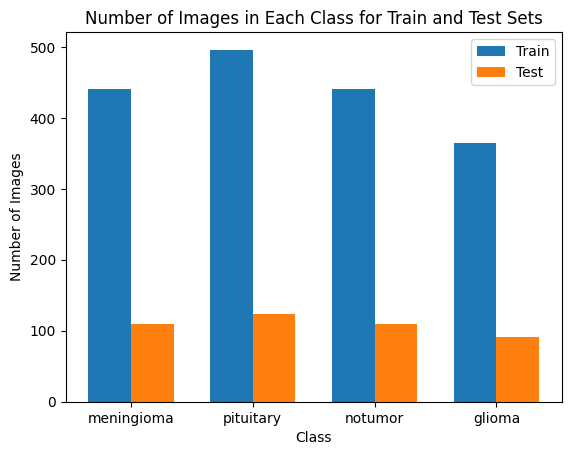

In [39]:
dataset_directory = '/content/drive/MyDrive/BrainTumorLabeledDataset'
train_directory = os.path.join(dataset_directory, 'train')
test_directory = os.path.join(dataset_directory, 'test')
print(train_directory)
print(test_directory)
plot_image_counts(train_directory, test_directory)

In [5]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Chargement du modèle ResNet50 préentraîné sur ImageNet

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Geler les poids du modèle de base
base_model.trainable = False

# Ajouter des couches au-dessus de ResNet50

x = base_model.output
x = GlobalAveragePooling2D()(x)  # Pooling global
x = Dense(1024, activation='relu')(x)  # Couche fully connected
x = Dropout(0.5)(x)  # Ajout de Dropout pour éviter le sur-apprentissage
predictions = Dense(4, activation='softmax')(x)  # 4 classes pour la sortie

# Définir le modèle final
model = Model(inputs=base_model.input, outputs=predictions)

# Compiler le modèle
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['recall'])

# Résumé du modèle
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 25,689,988 (98.00 MB)

 Trainable params: 2,102,276 (8.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [6]:
# Entraînement du modèle
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=100,  # Vous pouvez ajuster ce nombre selon vos besoins
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


43/43 ━━━━━━━━━━━━━━━━━━━━ 946s 20s/step - loss: 1.5863 - recall: 0.1876 - val_loss: 1.2171 - val_recall: 0.1125
Epoch 2/100
 1/43 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - loss: 1.2865 - recall: 0.1250

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 443ms/step - loss: 1.2865 - recall: 0.1250 - val_loss: 1.3635 - val_recall: 0.0000e+00
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 31s 651ms/step - loss: 1.2324 - recall: 0.1856 - val_loss: 1.2621 - val_recall: 0.1312
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1007 - recall: 0.2188 - val_loss: 1.1982 - val_recall: 0.1481
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 40s 649ms/step - loss: 1.2176 - recall: 0.1586 - val_loss: 1.2554 - val_recall: 0.1000
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.1631 - recall: 0.2188 - val_loss: 1.2484 - val_recall: 0.2593
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 31s 641ms/step - loss: 1.1740 - recall: 0.2063 - val_loss: 1.2058 - val_recall: 0.1063
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.2264 - recall: 0.1875 - val_loss: 1.1332 - val_recall: 0.1111
Epoch 9/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 31s 612ms/step - loss: 1.1893 - recall: 0.1599 - val_loss: 1.2115 - val_recall: 0.1094
Epoch 10/

In [7]:
# Évaluation du modèle sur les données de test
test_loss, test_recall = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f'Test Loss: {test_loss}, Test Recall: {test_recall}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 249s 21s/step - loss: 1.0698 - recall: 0.2374
Test Loss: 1.0437829494476318, Test Recall: 0.2475961595773697


In [12]:
!pip install ultralytics
from ultralytics import YOLO

  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 876.6/876.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 11.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 MB 10.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 11.1 MB/s eta 0:00:00a 0:00:01
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/macbook/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [13]:
# Load a model
model = YOLO("yolov8n-cls.pt")  # load a pretained model

# Use the model
results = model.train(data=dataset_BrainTumorLabeled, epochs=10, imgsz=64)  # train the model

100%|██████████| 5.31M/5.31M [00:00<00:00, 7.89MB/s]


Ultralytics 8.3.17 🚀 Python-3.10.6 torch-2.2.2 CPU (Intel Core(TM) i5-8257U 1.40GHz)
engine/trainer: task=classify, mode=train, model=yolov8n-cls.pt, data=/Users/macbook/code/Soumiabenhamou90/Brain-Tumor-Detection/raw_data/BrainTumorlabeleddataset, epochs=10, time=None, patience=100, batch=16, imgsz=64, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save

train: Scanning /Users/macbook/code/Soumiabenhamou90/Brain-Tumor-Detection/raw_data/BrainTumorlabeleddataset/train... 1740 images, 0 corrupt: 100%|██████████| 1740/1740 [00:00<00:00, 2138.26it/s]

train: New cache created: /Users/macbook/code/Soumiabenhamou90/Brain-Tumor-Detection/raw_data/BrainTumorlabeleddataset/train.cache



val: Scanning /Users/macbook/code/Soumiabenhamou90/Brain-Tumor-Detection/raw_data/BrainTumorlabeleddataset/test... 435 images, 0 corrupt: 100%|██████████| 435/435 [00:00<00:00, 2337.72it/s]

...

      10/10         0G     0.4517         12         64: 100%|██████████| 109/109 [00:37<00:00,  2.93it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 14/14 [00:06<00:00,  2.12it/s]

                   all      0.871          1



10 epochs completed in 0.111 hours.
Optimizer stripped from runs/classify/train/weights/last.pt, 3.0MB
Optimizer stripped from runs/classify/train/weights/best.pt, 3.0MB

Validating runs/classify/train/weights/best.pt...
Ultralytics 8.3.17 🚀 Python-3.10.6 torch-2.2.2 CPU (Intel Core(TM) i5-8257U 1.40GHz)
YOLOv8n-cls summary (fused): 73 layers, 1,440,004 parameters, 0 gradients, 3.3 GFLOPs
WARNING ⚠️ Dataset 'split=val' not found, using 'split=test' instead.
train: /Users/macbook/code/Soumiabenhamou90/Brain-Tumor-Detection/raw_data/BrainTumorlabeleddataset/train... found 1740 images in 4 classes ✅ 
val: None...
test: /Users/macbook/code/Soumiabenhamou90/Brain-Tumor-Detection/raw_data/BrainTumorlabeleddataset/test... found 435 images in 4 classes ✅ 


               classes   top1_acc   top5_acc: 100%|██████████| 14/14 [00:05<00:00,  2.47it/s]


                   all      0.878          1
Speed: 0.0ms preprocess, 3.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/train


In [40]:
# Load a model
model = YOLO("yolov8n-cls.pt")  # load a pretained model

# Use the model
results = model.train(data='/content/drive/MyDrive/BrainTumorLabeledDataset', epochs=10, imgsz=64)  # train the model

100%|██████████| 5.31M/5.31M [00:00<00:00, 166MB/s]


Ultralytics 8.3.17 🚀 Python-3.10.12 torch-2.4.1+cu121 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=classify, mode=train, model=yolov8n-cls.pt, data=/content/drive/MyDrive/BrainTumorLabeledDataset, epochs=10, time=None, patience=100, batch=16, imgsz=64, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, sho

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:


Abort: 